# Movie Data Exploratory Analysis

## Objective

Explore which measurable movie characteristics are associated with worldwide gross revenue, compare revenue across genres, and assess a simple revenue-efficiency ratio. This is an exploratory analysis: associations do not establish that one variable causes another.

## Analytical questions

1. Which meaningful numerical variables are most strongly associated with gross revenue?
2. How are production budget and gross revenue associated?
3. How are audience votes and scores associated with gross revenue?
4. Do genres show different typical gross revenues?
5. What does gross-to-budget revenue efficiency show for movies with reported positive budgets?

In [1]:
from pathlib import Path
import os


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data" / "movies.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/movies.csv from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

DATA_PATH = PROJECT_ROOT / "data" / "movies.csv"
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

## Dataset overview

The supplied file contains movie metadata and financial fields. The original repository did not document the publisher, download date, currency definition, or whether `gross` is domestic or worldwide, so financial results are described using the dataset's labels rather than stronger claims.

In [2]:
raw = pd.read_csv(DATA_PATH)

overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": (100 * raw.isna().mean()).round(2),
    "unique_values": raw.nunique(dropna=True),
})

print(f"Rows: {len(raw):,}")
print(f"Columns: {raw.shape[1]}")
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
display(overview)

Rows: 7,668
Columns: 15
Exact duplicate rows: 0


,dtype,missing,missing_pct,unique_values
name,str,0,0.00,7512
rating,str,77,1.00,12
genre,str,0,0.00,19
year,int64,0,0.00,41
released,str,2,0.03,3414
score,float64,3,0.04,72
votes,float64,3,0.04,936
director,str,0,0.00,2949
writer,str,3,0.04,4535
star,str,1,0.01,2814


In [3]:
numeric_checks = pd.Series({
    "nonpositive_budget": raw["budget"].le(0).sum(),
    "nonpositive_gross": raw["gross"].le(0).sum(),
    "nonpositive_runtime": raw["runtime"].le(0).sum(),
    "score_outside_0_to_10": (~raw["score"].between(0, 10) & raw["score"].notna()).sum(),
    "year_below_1888_or_above_2020": (~raw["year"].between(1888, 2020)).sum(),
})

display(numeric_checks.to_frame("row_count"))
display(raw[["rating", "genre"]].nunique().rename("distinct_values").to_frame())

,row_count
nonpositive_budget,0
nonpositive_gross,0
nonpositive_runtime,0
score_outside_0_to_10,0
year_below_1888_or_above_2020,0


,distinct_values
rating,12
genre,19


## Data quality and cleaning decisions

- **Duplicates:** remove exact duplicates if present; none exist in the supplied file.
- **Release date:** remove the trailing country text and parse it as a date. Two missing dates remain missing.
- **Gross revenue:** do not impute. Exclude its 189 missing rows only from revenue-dependent analyses.
- **Budget:** do not mean-impute the 2,171 missing values. Budget comparisons and efficiency use only reported positive budgets.
- **Score, votes, and runtime:** retain missing values and use pairwise complete observations. Only three, three, and four rows are missing respectively.
- **Rating, company, writer, star, and country:** leave missing because they are not required for the selected questions.

This preserves uncertainty and avoids creating artificial values that could distort correlations or grouped summaries.

In [4]:
movies = raw.drop_duplicates().copy()

release_text = movies["released"].astype("string").str.replace(
    r"\s*\([^)]*\)\s*$", "", regex=True
)
movies["release_date"] = pd.to_datetime(release_text, errors="coerce", format="mixed")
movies["release_year"] = movies["release_date"].dt.year

for column in ["budget", "gross", "votes", "runtime", "score"]:
    movies[column] = pd.to_numeric(movies[column], errors="coerce")

release_year_mismatches = (
    movies["release_year"].notna() & movies["year"].ne(movies["release_year"])
).sum()

print(f"Rows retained after exact deduplication: {len(movies):,}")
print(f"Unparsed or missing release dates: {movies['release_date'].isna().sum():,}")
print(f"Rows where listed year differs from parsed release year: {release_year_mismatches:,}")

Rows retained after exact deduplication: 7,668
Unparsed or missing release dates: 2
Rows where listed year differs from parsed release year: 1,324


The parsed release year differs from the listed `year` for many rows, likely because festival, limited, and international releases can occur in different years. The analysis uses the parsed release year where a time variable is needed and does not treat the mismatch as automatically erroneous.

## Exploratory analysis

### Gross-revenue distribution

A logarithmic horizontal scale makes the strongly right-skewed distribution readable without changing the stored revenue values.

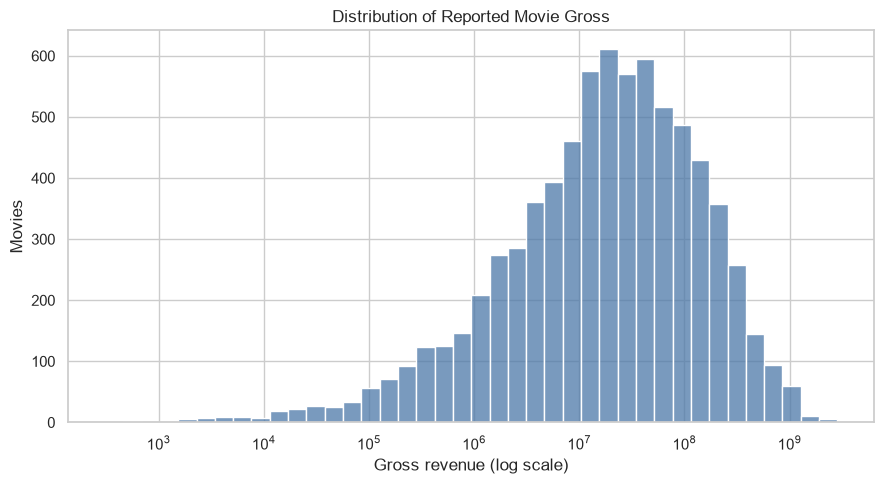

,gross
count,7.479000e+03
mean,7.850054e+07
std,1.657251e+08
min,3.090000e+02
25%,4.532056e+06
50%,2.020576e+07
75%,7.601669e+07
max,2.847246e+09


In [5]:
gross_data = movies.loc[movies["gross"].gt(0), "gross"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(gross_data, bins=40, log_scale=True, ax=ax, color="#4C78A8")
ax.set(title="Distribution of Reported Movie Gross", xlabel="Gross revenue (log scale)", ylabel="Movies")
fig.tight_layout()
fig.savefig(IMAGE_DIR / "gross_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

gross_data.describe(percentiles=[0.25, 0.5, 0.75]).to_frame("gross")

Reported gross is highly right-skewed: a relatively small number of high-grossing movies sit far above the typical observation. Medians and logarithmic visual scales are therefore useful complements to averages and raw-scale charts.

## Correlation analysis

Pearson correlation is limited to continuous or meaningfully ordered numerical variables. Categories such as genre, company, director, and rating are **not** integer-encoded or included in the matrix.

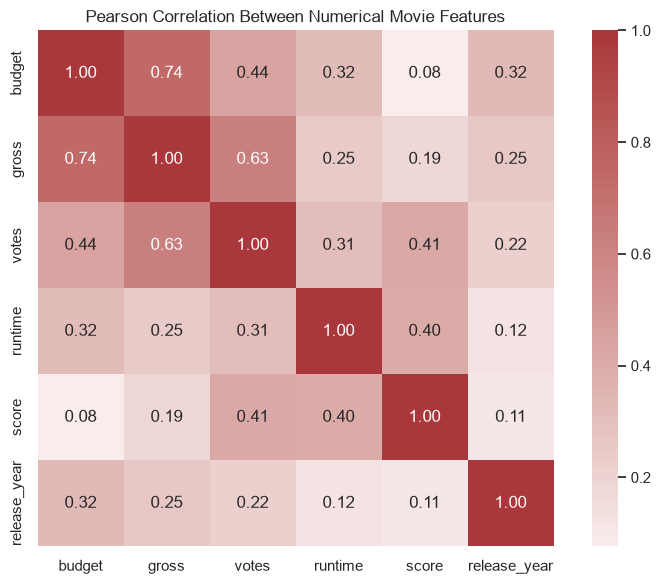

,correlation_with_gross
budget,0.740395
votes,0.630757
release_year,0.250514
runtime,0.245216
score,0.186258


In [6]:
numeric_features = ["budget", "gross", "votes", "runtime", "score", "release_year"]
numeric_correlation = movies[numeric_features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    numeric_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Pearson Correlation Between Numerical Movie Features")
fig.tight_layout()
fig.savefig(IMAGE_DIR / "numeric_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

numeric_correlation["gross"].drop("gross").sort_values(ascending=False).to_frame(
    "correlation_with_gross"
)

Budget has the strongest positive linear association with gross revenue, followed by vote count. Runtime, release year, and score have weaker positive associations. These are observational relationships: correlation does not imply that increasing any feature would cause higher revenue.

### Budget and gross revenue

The chart uses only movies with reported positive budget and gross values. Both axes are transformed to base-10 logarithms because the financial variables span several orders of magnitude.

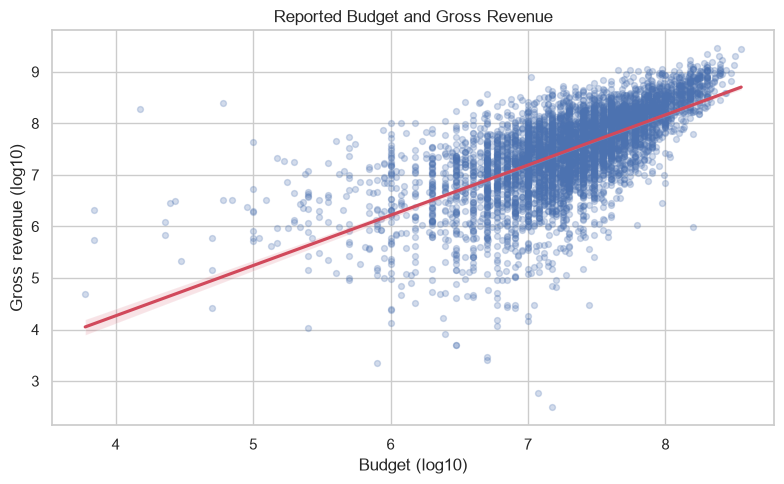

Movies with reported positive budget and gross: 5,436
Raw-value Pearson correlation: 0.740


In [7]:
budget_gross = movies.dropna(subset=["budget", "gross"]).query("budget > 0 and gross > 0").copy()
budget_gross["log10_budget"] = np.log10(budget_gross["budget"])
budget_gross["log10_gross"] = np.log10(budget_gross["gross"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=budget_gross,
    x="log10_budget",
    y="log10_gross",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#D1495B"},
    ax=ax,
)
ax.set(
    title="Reported Budget and Gross Revenue",
    xlabel="Budget (log10)",
    ylabel="Gross revenue (log10)",
)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "budget_vs_gross.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Movies with reported positive budget and gross: {len(budget_gross):,}")
print(f"Raw-value Pearson correlation: {budget_gross['budget'].corr(budget_gross['gross']):.3f}")

The upward pattern supports a strong positive association between reported budget and gross. The wide dispersion around the trend also shows that budget alone does not determine commercial performance.

### Audience engagement and gross revenue

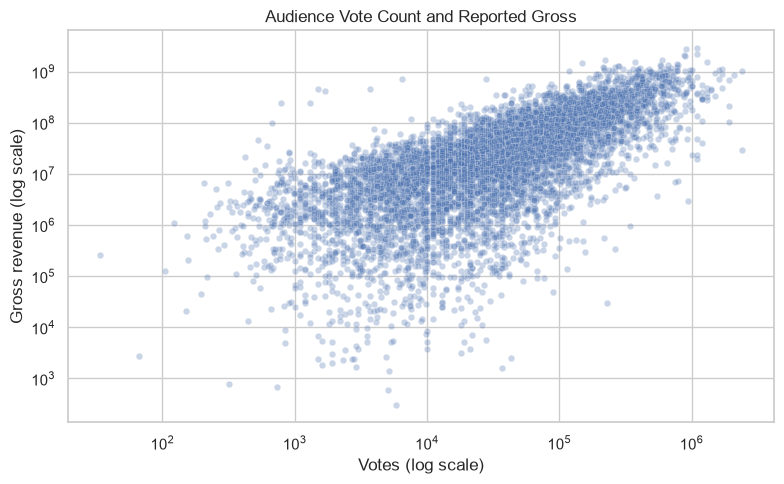

,pearson_correlation
votes_vs_gross,0.631
score_vs_gross,0.186


In [8]:
votes_gross = movies.dropna(subset=["votes", "gross"]).query("votes > 0 and gross > 0").copy()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=votes_gross, x="votes", y="gross", alpha=0.3, s=22, ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(
    title="Audience Vote Count and Reported Gross",
    xlabel="Votes (log scale)",
    ylabel="Gross revenue (log scale)",
)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "votes_vs_gross.png", dpi=160, bbox_inches="tight")
plt.show()

pd.Series({
    "votes_vs_gross": movies[["votes", "gross"]].corr().iloc[0, 1],
    "score_vs_gross": movies[["score", "gross"]].corr().iloc[0, 1],
}).round(3).to_frame("pearson_correlation")

Vote count has a moderately strong positive association with gross, while audience score has a much weaker association. Vote count is also an exposure measure—widely seen movies have more opportunities to receive votes—so its relationship with gross should not be interpreted causally.

### Gross revenue by genre

Genres are compared using medians and sample sizes rather than arbitrary category codes. The chart includes categories with at least 50 reported-gross observations to reduce emphasis on very small groups.

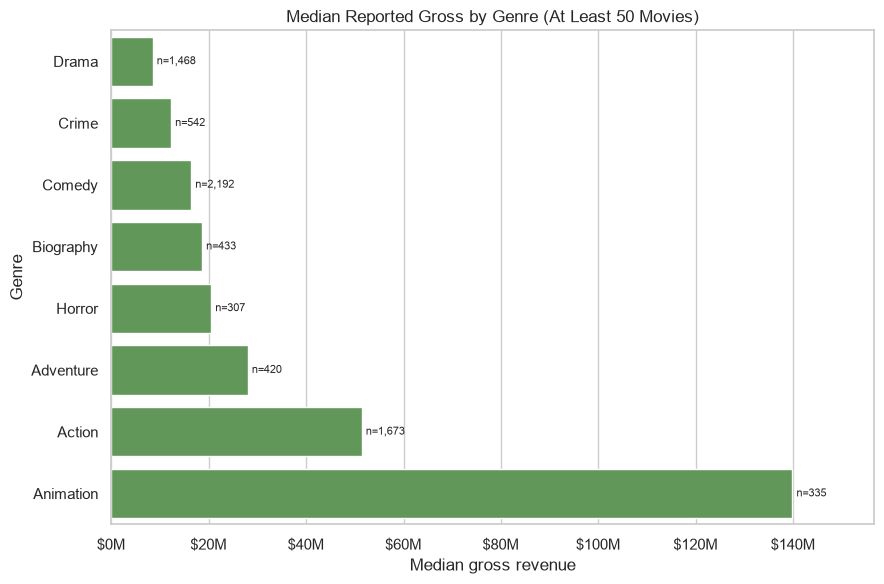

,genre,movie_count,median_gross
2,Animation,335,139804348.0
0,Action,1673,51386477.0
1,Adventure,420,27989799.0
9,Horror,307,20471382.0
8,Fantasy,43,19595031.0
12,Mystery,20,19255503.5
3,Biography,433,18598607.0
4,Comedy,2192,16373597.0
5,Crime,542,12239344.5
16,Thriller,12,12105479.0


In [9]:
genre_summary = (
    movies.dropna(subset=["gross"])
    .groupby("genre", as_index=False)
    .agg(movie_count=("gross", "size"), median_gross=("gross", "median"))
)
genre_chart = genre_summary.query("movie_count >= 50").sort_values("median_gross", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=genre_chart, x="median_gross", y="genre", color="#59A14F", ax=ax)
ax.set(title="Median Reported Gross by Genre (At Least 50 Movies)", xlabel="Median gross revenue", ylabel="Genre")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value / 1_000_000:.0f}M"))
ax.margins(x=0.12)
for container in ax.containers:
    ax.bar_label(container, labels=[f"n={n:,}" for n in genre_chart["movie_count"]], padding=3, fontsize=8)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "genre_median_gross.png", dpi=160, bbox_inches="tight")
plt.show()

genre_summary.sort_values("median_gross", ascending=False).head(10)

Animation and action have the highest median reported gross among the larger genre groups. This comparison is descriptive: genre groups differ in release period, budget, franchise mix, distribution, and sample size.

## Level-up: revenue efficiency

Revenue efficiency is defined as `gross / budget` only where both fields are reported and positive. It is a gross-return multiple—not profit or return on investment—because marketing, distribution, exhibitor shares, financing, and other costs are unavailable.

In [10]:
efficiency = budget_gross.assign(revenue_efficiency=budget_gross["gross"] / budget_gross["budget"])

efficiency_summary = efficiency["revenue_efficiency"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]
).to_frame()
genre_efficiency = (
    efficiency.groupby("genre", as_index=False)
    .agg(movie_count=("revenue_efficiency", "size"), median_efficiency=("revenue_efficiency", "median"))
    .query("movie_count >= 50")
    .sort_values("median_efficiency", ascending=False)
)

display(efficiency_summary)
display(genre_efficiency)

,revenue_efficiency
count,5436.000000
mean,6.719253
std,183.843156
min,0.000021
25%,0.723229
50%,1.832878
75%,3.671363
90%,7.118047
max,12890.386667


,genre,movie_count,median_efficiency
9,Horror,254,3.047218
2,Animation,278,2.929611
1,Adventure,327,1.877967
0,Action,1417,1.872290
4,Comedy,1496,1.787556
6,Drama,869,1.526437
3,Biography,312,1.476405
5,Crime,400,1.314690


The median reported gross is about 1.83 times the reported budget among complete positive-budget observations. Extreme multiples and missing budgets make this a screening metric rather than a profitability estimate.

## Key findings

- **Budget and gross:** strongest numerical association with gross (`r ≈ 0.74`), with substantial variation around the trend.
- **Votes and gross:** moderately strong association (`r ≈ 0.63`); vote count likely reflects audience exposure as well as engagement.
- **Score and gross:** comparatively weak association (`r ≈ 0.19`).
- **Genre:** animation and action have the highest median gross among genre groups with substantial samples.
- **Efficiency:** the median gross-to-budget multiple is approximately 1.83 for movies with both values reported and positive.

These results describe association within the supplied data and do not establish causal effects.

## Limitations

- Dataset provenance, collection date, currency, inflation basis, and gross-revenue definition are undocumented.
- Budget is missing for roughly 28% of rows; complete-budget analysis may not represent all movies.
- Financial values are nominal and are not adjusted for inflation or release market.
- Genres are represented by one label per movie and may hide multi-genre characteristics.
- Pearson correlation measures linear association and is sensitive to skew and outliers.
- Vote totals, budgets, distribution reach, franchise status, and release timing are interrelated; no causal conclusions are supported.
- Revenue efficiency excludes important costs and is not profitability or ROI.